# Assignment 2. Option 2

## Dataset Exploration

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
!bash ./src/download_voxconverse.sh

Annotations already present, skipping clone.
Audio already present, skipping download.


## Pyannote-Based System

## Custom Implementation (PyTorch / Torchaudio / PyTorch-Lightning)

In [3]:
from pathlib import Path
from src.dataset import *
from src.models import *
from src.train import *
from torch.utils.data import DataLoader
import soundfile as sf
import torch
import matplotlib.pyplot as plt

DATA_DIR = Path("data")
AUDIO_DIR = DATA_DIR / "audio"
ANNOTATIONS_DIR = DATA_DIR / "annotations"
IMG_DIR = Path("img")
MODELS_DIR = Path("models")
DIR_DEV = "dev"
DIR_TEST = "test"
SAMPLE_RATE = 16_000
HOP = 10
VAD_MODEL = MODELS_DIR / "vad.pt"
SEGMENTATOR_MODEL = MODELS_DIR / "segmentator.pt"

device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"

In [4]:
dataset_dev = VoxConverseDataset(
  annotations_dir=ANNOTATIONS_DIR / DIR_DEV,
  audio_dir=AUDIO_DIR / DIR_DEV,
  sample_rate=SAMPLE_RATE,
)

dataset_test = VoxConverseDataset(
  annotations_dir=ANNOTATIONS_DIR / DIR_TEST,
  audio_dir=AUDIO_DIR / DIR_TEST,
  sample_rate=SAMPLE_RATE,
)

dev_lengths  = [sf.info(p).frames for p in dataset_dev.audio_files]
test_lengths = [sf.info(p).frames for p in dataset_test.audio_files]

dataloader_dev = DataLoader(
  dataset_dev,
  batch_sampler=AudioSampler(dev_lengths, batch_size=8, shuffle=True),
  collate_fn=make_agnostic_collate_fn(HOP, SAMPLE_RATE),
)

dataloader_test = DataLoader(
  dataset_test,
  batch_sampler=AudioSampler(test_lengths, batch_size=8, shuffle=False),
  collate_fn=make_agnostic_collate_fn(HOP, SAMPLE_RATE),
)

### A Voice Activity Detection (VAD) model using a supervised neural network approach

<div align="center"><img src="img/vad.png" height="800"></div>

In [5]:
VAD_RETRAIN=False

vad = VoiceActivityDetector(
  device=device,
  spectrogram_layer=MelSpectrogramExtractor(
    sample_rate=SAMPLE_RATE,
    hop_ms=HOP,
  )
)

if VAD_MODEL.exists() and not VAD_RETRAIN:
  vad.load_state_dict(torch.load(VAD_MODEL, weights_only=True))
  print(f"VAD loaded from {VAD_MODEL}")
else:
  epochs = 7
  lr = 1e-3

  print(f"Device: {device}")

  history = train_vad(vad, device, lr, epochs, dataloader_dev, dataloader_test)
  fig = plot_history(history)
  fig.savefig(IMG_DIR / "vad_metrics.png", dpi=150, bbox_inches="tight")
  fig.show()

  torch.save(vad.state_dict(), VAD_MODEL)

VAD loaded from models/vad.pt


54090 -> 1691   ratio: 31.986989946777054


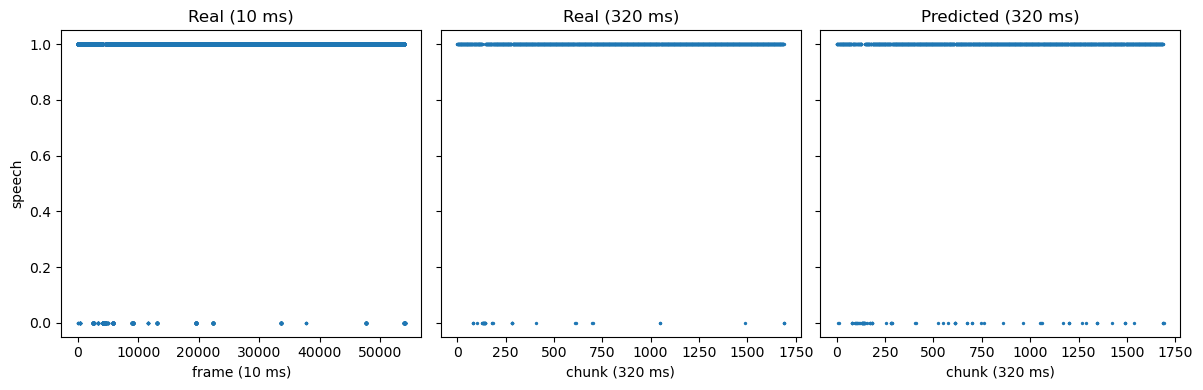

In [6]:
(waveform, labels, mask) = next(iter(dataloader_dev))

m10 = mask[0]
y10 = labels[0][m10].numpy()

with torch.no_grad():
    vad.eval()
    x = tuple(t for t in (waveform, labels, mask))
    pred, labels_c, mask_c = vad(x)

    m0     = mask_c[0]
    truth0 = labels_c[0][m0].cpu().numpy()
    pred0  = (torch.sigmoid(pred[0]) > 0.5)[m0].cpu().numpy()

print(len(y10), "->", len(truth0), "  ratio:", len(y10) / len(truth0))  # expect ~32

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 4), sharey=True)

ax1.scatter(range(len(y10)), y10, s=2)
ax1.set(title="Real (10 ms)", xlabel="frame (10 ms)", ylabel="speech")

ax2.scatter(range(len(truth0)), truth0, s=2)
ax2.set(title="Real (320 ms)", xlabel="chunk (320 ms)")

ax3.scatter(range(len(pred0)), pred0, s=2)
ax3.set(title="Predicted (320 ms)", xlabel="chunk (320 ms)")

fig.tight_layout()


### A segmentation model utilizing permutation invariant CE loss.

In [7]:
annfile, count = find_max_speakers(dataset_dev)
print(f"Max speakers in dev dataset: {count} - {annfile}")

annfile, count = find_max_speakers(dataset_test)
print(f"Max speakers in test dataset: {count} - {annfile}")

Max speakers in dev dataset: 20 - data/annotations/dev/kdfqk.rttm
Max speakers in test dataset: 21 - data/annotations/test/nitgx.rttm


In [8]:
from src.dataset import *

dataloader_dev = DataLoader(
  dataset_dev,
  batch_sampler=AudioSampler(dev_lengths, batch_size=1, shuffle=False),
  collate_fn=make_collate_fn(HOP, SAMPLE_RATE),
)

dataloader_test = DataLoader(
  dataset_test,
  batch_sampler=AudioSampler(test_lengths, batch_size=8, shuffle=False),
  collate_fn=make_collate_fn(HOP, SAMPLE_RATE),
)

In [ ]:
SEGMENTATOR_RETRAIN=False

segmentator = Segmentator(
  device=device,
  spectrogram_layer=MelSpectrogramExtractor(sample_rate=SAMPLE_RATE, hop_ms=HOP),
)

if SEGMENTATOR_MODEL.exists() and not SEGMENTATOR_RETRAIN:
  segmentator.load_state_dict(torch.load(SEGMENTATOR_MODEL, weights_only=True))
  print(f"Segmentator loaded from {VAD_MODEL}")
else:
  epochs = 3
  lr = 1e-3

  print(f"Device: {device}")

  history = train_segmentator(segmentator, device, lr, epochs, dataloader_dev, dataloader_test)
  fig = plot_history(history)
  fig.savefig(IMG_DIR / "segmentator_metrics.png", dpi=150, bbox_inches="tight")
  fig.show()

  torch.save(segmentator.state_dict(), SEGMENTATOR_MODEL)

Device: mps
===== EPOCH 1/3 - train =====
  batch   1 | loss 0.6596 | acc 0.924 | P 0.317 | R 0.330 | F1 0.323 | spec 0.611


In [12]:
list(itertools.permutations(range(3)))

[(0, 1, 2), (0, 2, 1), (1, 0, 2), (1, 2, 0), (2, 0, 1), (2, 1, 0)]

In [ ]:
sample = next(iter(dataloader_test))
segmentator.eval()

waveform, in_labels, in_mask = sample
with torch.no_grad():
    logits, tgt, m = model(tuple(t.to(device) for t in sample))
# (B, W, T, K), (B, W, T, K), (B, W, T) — assume B = 1
logits, tgt, m = logits[0], tgt[0], m[0].bool()           # -> (W, T, K), (W, T, K), (W, T)
probs = torch.sigmoid(logits)

# inspect the window with the most active speakers
w = int((tgt.sum(1) > 0).sum(1).argmax())

# --- PIT-align predicted slots to the target's slot order for this window ---
def best_perm(lg, tg, mk):                                # (T,K),(T,K),(T,)
    mk = mk[:, None].float()
    def cost(p):
        bce = (p.clamp(min=0) - p * tg + torch.log1p((-p.abs()).exp())) * mk
        return float(bce.sum())
    return min(itertools.permutations(range(tg.shape[1])), key=lambda pm: cost(lg[:, pm]))

perm = best_perm(logits[w], tgt[w].float(), m[w])
probs_w = probs[w][:, perm]                               # aligned to target order

# --- time axis: this window's absolute span in the recording ---
hop_ms = model.spectrogram.hop_ms
win = int(model.window_size / hop_ms)
hop = int(model.window_step / hop_ms)
start = w * hop
t = (np.arange(win) + start) * hop_ms / 1000.0           # seconds

# --- original input labels, sliced to the same span ---
il = in_labels[0].cpu().numpy()                          # (K_full, T_full)
sl = il[:, start:start + win]
if sl.shape[1] < win:                                    # last window runs into padding
    sl = np.pad(sl, ((0, 0), (0, win - sl.shape[1])))
keep = sl.any(1)                                         # only speakers active here

def gantt(ax, act, ylabels, title):
    cmap = plt.cm.tab10
    for i in range(act.shape[1]):
        ax.step(t, i + act[:, i] * 0.8, where='post', color=cmap(i % 10), lw=1.4)
        ax.axhline(i, color='0.9', lw=0.5, zorder=0)
    ax.set_yticks(range(len(ylabels))); ax.set_yticklabels(ylabels)
    ax.set_title(title); ax.set_ylim(-0.2, len(ylabels))

fig, ax = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
gantt(ax[0], sl[keep].T, [f"spk {i}" for i in np.where(keep)[0]],
      f"1. Input labels — window {w} ({keep.sum()} speakers active)")
gantt(ax[1], tgt[w].cpu().numpy().astype(float), [f"slot {i}" for i in range(tgt.shape[1])],
      "2. Target — packed kmax slots")
gantt(ax[2], probs_w.cpu().numpy(), [f"slot {i}" for i in range(tgt.shape[1])],
      "3. Prediction — sigmoid, PIT-aligned (line height = probability)")
ax[2].set_xlabel("time (s)")
plt.tight_layout(); plt.show()